# Directional Grid Advection with Graph Attention

This notebook trains a **GraphKoopmanModel** with a **GATEncoder** on a 2D lattice
where node features propagate **directionally** — mostly from west and north
neighbors. That asymmetric coupling is a setting where attention can learn
*which* neighbors matter, while GCN layers tend to aggregate all neighbors
uniformly.

We use :class:`~koopman_graph.datasets.AnisotropicAdvectionGridBenchmark` and
compare GAT against a GCN encoder on the same rollout task.


## The encode → Koopman step → decode workflow

1. **Encode (GAT lifting):** Graph attention maps node features into latent space
   while learning neighbor importance.
2. **Koopman step:** A learned matrix $K$ advances latent states linearly.
3. **Decode:** A GCN decoder maps latent states back to physical features.

Training includes an autoregressive rollout term so multi-step `predict` matches
the optimization objective.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import random

import numpy as np
import torch

from koopman_graph import GATEncoder, GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import AnisotropicAdvectionGridBenchmark
from koopman_graph.datasets.grid import anisotropic_advection_step, grid_node_index
from koopman_graph.training import constant_loss_weights

MODEL_SEED = 0
random.seed(MODEL_SEED)
np.random.seed(MODEL_SEED)
torch.manual_seed(MODEL_SEED)


## Generate advection grid data

`AnisotropicAdvectionGridBenchmark` builds an $8 \times 8$ lattice. Each node
keeps a self-retention fraction `decay_rate` (default $0.85$) and mixes the
remaining mass $(1-\text{decay\_rate})$ over neighbors:

$$
x_{t+1} = \text{decay\_rate}\, x_t
  + (1-\text{decay\_rate})\,
    \frac{\sum_{j\in\mathcal{N}(i)} w_{ij} x_{j,t}}
         {\sum_{j\in\mathcal{N}(i)} w_{ij}}.
$$

Default neighbor weights are $w_{\text{west}}=0.7$, $w_{\text{north}}=0.2$, with
the leftover $0.1$ shared among other available neighbors, then renormalized by
the assigned-weight sum (borders omit missing directions). West is therefore
**not** $70\%$ of the full update — only of the neighbor-mixture term.

Because each node **pulls from** its western neighbor, a perturbation on the
west side influences nodes to its east over time (eastward propagation of
information — not “west stays larger”).


In [2]:
IS_CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
NUM_ROWS = 4 if IS_CI else 8
NUM_COLS = 4 if IS_CI else 8
NUM_TIMESTEPS = 24 if IS_CI else 40

data_sequence = AnisotropicAdvectionGridBenchmark.generate(
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=3,
    seed=42,
    decay_rate=0.85,
    west_weight=0.7,
    north_weight=0.2,
    noise_std=0.005,
)

print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Nodes: {data_sequence.num_nodes}")
print(f"Edges: {data_sequence.edge_index.shape[1]}")
print(f"Feature dim: {data_sequence.in_channels}")


Snapshots: 40
Nodes: 64
Edges: 224
Feature dim: 3


Directional check (noiseless **west-column impulse**, not the training IC):
raise column 0, then step with
:func:`~koopman_graph.datasets.grid.anisotropic_advection_step`
(`noise_std=0`). West-edge mean decays while the east-edge mean rises later —
eastward influence from “pull from the west neighbor.”

The heatmap is dominated by the west→east gradient. Weak north–south variation
from `north_weight` and top/bottom borders is real but often hard to see on
this color scale.

The training sequence above stays `ones` + small noise. On that near-uniform
field, west/east edge means can still split because **borders omit missing
directions** (the west edge never applies \(w_{\text{west}}\)) and therefore
filter noise differently; that split is not itself a plume diagram.


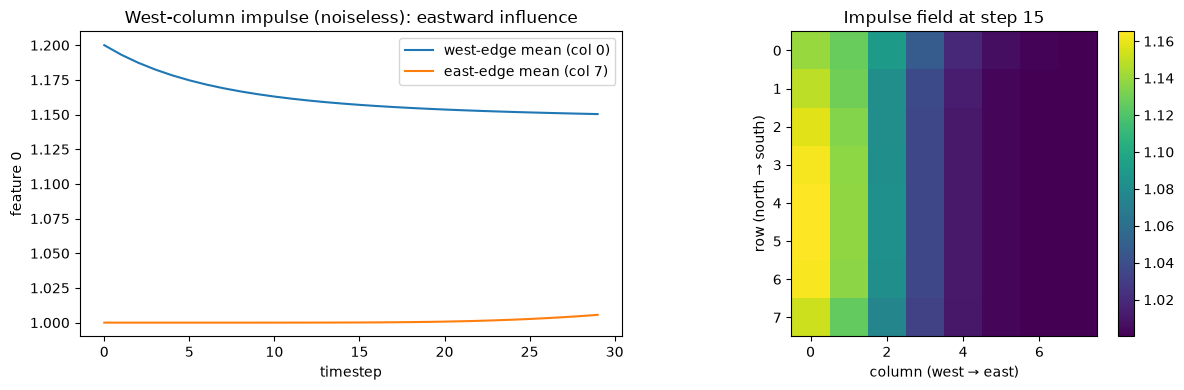

In [3]:
feature_idx = 0
decay_rate = 0.85
west_weight = 0.7
north_weight = 0.2
impulse_steps = 30
west_nodes = [grid_node_index(row, 0, num_cols=NUM_COLS) for row in range(NUM_ROWS)]
east_nodes = [
    grid_node_index(row, NUM_COLS - 1, num_cols=NUM_COLS) for row in range(NUM_ROWS)
]

state = torch.ones(NUM_ROWS * NUM_COLS, data_sequence.in_channels)
state[west_nodes, feature_idx] = 1.2
impulse_west: list[float] = []
impulse_east: list[float] = []
impulse_field = state[:, feature_idx].reshape(NUM_ROWS, NUM_COLS).clone()
for step in range(impulse_steps):
    impulse_west.append(state[west_nodes, feature_idx].mean().item())
    impulse_east.append(state[east_nodes, feature_idx].mean().item())
    if step == impulse_steps // 2:
        impulse_field = state[:, feature_idx].reshape(NUM_ROWS, NUM_COLS).clone()
    state = anisotropic_advection_step(
        state,
        num_rows=NUM_ROWS,
        num_cols=NUM_COLS,
        decay_rate=decay_rate,
        west_weight=west_weight,
        north_weight=north_weight,
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(impulse_west, label="west-edge mean (col 0)")
axes[0].plot(impulse_east, label=f"east-edge mean (col {NUM_COLS - 1})")
axes[0].set_xlabel("timestep")
axes[0].set_ylabel(f"feature {feature_idx}")
axes[0].set_title("West-column impulse (noiseless): eastward influence")
axes[0].legend()

im = axes[1].imshow(impulse_field.numpy(), origin="upper", aspect="equal")
axes[1].set_xlabel("column (west → east)")
axes[1].set_ylabel("row (north → south)")
axes[1].set_title(f"Impulse field at step {impulse_steps // 2}")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


## Build the GAT model

`GATEncoder` uses multi-head attention (`heads=4`) to lift node features. The
decoder remains a GCN, following the hybrid encoder/decoder design used
throughout KoopmanGraph.

**Capacity note.** With the same channel widths, `heads=4` gives the GAT
encoder more parameters than `GNNEncoder` (attention heads add weight matrices
even when `concat=False` keeps the channel width fixed). Treat the comparison
below as a pedagogical contrast — attention vs uniform aggregation — not a
parameter-matched ablation. A stricter control is `heads=1`.


In [4]:
in_channels = data_sequence.in_channels
hidden_channels = 64
latent_dim = 64
out_channels = in_channels

torch.manual_seed(MODEL_SEED)
gat_encoder = GATEncoder(
    in_channels,
    hidden_channels,
    latent_dim,
    heads=4,
    dropout=0.0,
)
decoder = GNNDecoder(latent_dim, hidden_channels, out_channels)
gat_model = GraphKoopmanModel(
    encoder=gat_encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=0.1,
)

print(gat_model)


GraphKoopmanModel(
  (encoder): GATEncoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GATConv(3, 64, heads=4)
      (1): GATConv(64, 64, heads=4)
    )
  )
  (decoder): GNNDecoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(64, 64)
      (1): GCNConv(64, 3)
    )
  )
  (koopman): KoopmanOperator()
)


## Train the GAT model


In [5]:
predict_steps = 4 if IS_CI else 10
EPOCHS = 12 if IS_CI else 120
loss_weights = constant_loss_weights(
    reconstruction=1.0,
    forward=1.0,
    rollout=2.0,
)

gat_history = gat_model.fit(
    data_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=predict_steps,
    max_grad_norm=1.0,
)

print(f"Initial loss: {gat_history.loss[0]:.6f}")
print(f"Final loss: {gat_history.loss[-1]:.6f}")


Initial loss: 3.052760
Final loss: 0.006459


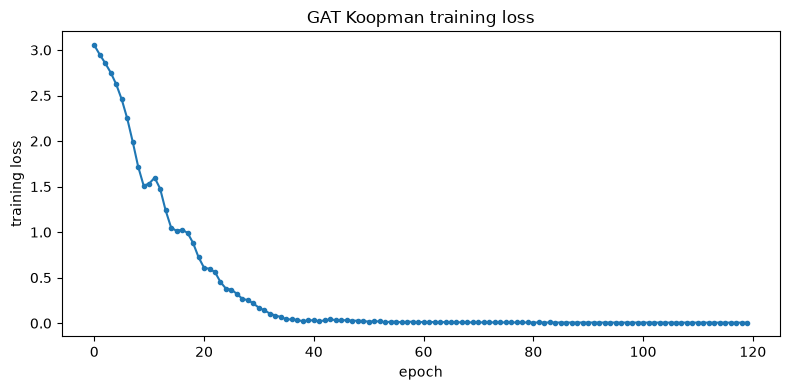

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gat_history.loss, marker="o", markersize=3)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("GAT Koopman training loss")
fig.tight_layout()
plt.show()


## Predict and compare with a GCN encoder

On **isotropic diffusion**, GCN and GAT often perform similarly. On this
**directional advection** benchmark, attention should outperform uniform
convolution because the ground-truth dynamics weight west/north neighbors
much more heavily than east/south.

We forecast from **snapshot 20** rather than the uniform initial state at
snapshot 0. Early transients are harder for a linear Koopman rollout to
track; a later window shows clearer encoder differences while still
following the advection trend.

The **printed rollout MSE** is the primary accuracy claim. It is **in-sample**:
the forecast origin lies on the same sequence used for training (no held-out
split)—a pedagogical encoder contrast, not a generalization claim. The figure
that follows pairs that global metric with one illustrative west-edge node —
useful for seeing qualitative behavior, not a substitute for the MSE.


In [7]:
rollout_start = 12 if IS_CI else 20
initial_graph = data_sequence[rollout_start]
gat_future = gat_model.predict(initial_graph, steps=predict_steps)
ground_truth = data_sequence[rollout_start + 1 : rollout_start + predict_steps + 1]

gat_mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(gat_future, ground_truth, strict=True)
        ]
    )
)
print(f"GAT rollout MSE: {gat_mse.item():.6f}")

torch.manual_seed(MODEL_SEED)
gcn_encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
gcn_model = GraphKoopmanModel(
    encoder=gcn_encoder,
    decoder=GNNDecoder(latent_dim, hidden_channels, out_channels),
    latent_dim=latent_dim,
    time_step=0.1,
)
gcn_model.fit(
    data_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=predict_steps,
    max_grad_norm=1.0,
)
gcn_future = gcn_model.predict(initial_graph, steps=predict_steps)
gcn_mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(gcn_future, ground_truth, strict=True)
        ]
    )
)
print(f"GCN rollout MSE: {gcn_mse.item():.6f}")
if gat_mse < gcn_mse:
    print("GAT encoder wins on directional advection (lower rollout MSE).")
else:
    print("GCN encoder wins on this window (lower rollout MSE).")


GAT rollout MSE: 0.001674
GCN rollout MSE: 0.002497
GAT encoder wins on directional advection (lower rollout MSE).


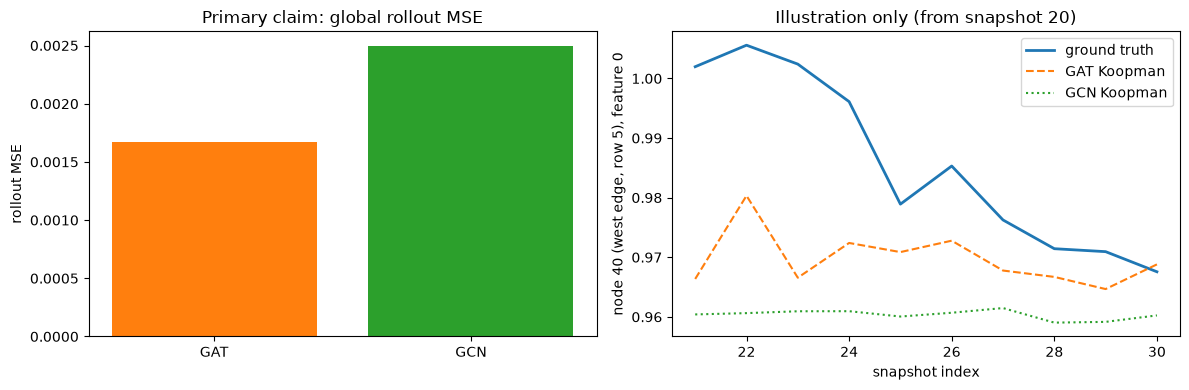

In [8]:
# Illustrative west-edge node: qualitative shape only — prefer the MSE bar (left).
plot_row = min(5, NUM_ROWS - 1)
plot_node = grid_node_index(plot_row, 0, num_cols=NUM_COLS)
gat_values = torch.stack([graph.x[plot_node, feature_idx] for graph in gat_future])
gcn_values = torch.stack([graph.x[plot_node, feature_idx] for graph in gcn_future])
truth_values = torch.stack([graph.x[plot_node, feature_idx] for graph in ground_truth])
pred_times = torch.arange(rollout_start + 1, rollout_start + predict_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(
    ["GAT", "GCN"],
    [gat_mse.item(), gcn_mse.item()],
    color=["C1", "C2"],
)
axes[0].set_ylabel("rollout MSE")
axes[0].set_title("Primary claim: global rollout MSE")

axes[1].plot(pred_times, truth_values.numpy(), label="ground truth", linewidth=2)
axes[1].plot(pred_times, gat_values.numpy(), label="GAT Koopman", linestyle="--")
axes[1].plot(pred_times, gcn_values.numpy(), label="GCN Koopman", linestyle=":")
axes[1].set_xlabel("snapshot index")
axes[1].set_ylabel(f"node {plot_node} (west edge, row {plot_row}), feature {feature_idx}")
axes[1].set_title(f"Illustration only (from snapshot {rollout_start})")
axes[1].legend()
fig.tight_layout()
plt.show()


## Takeaways

- **Directional result:** On this anisotropic advection window (snapshot 20,
  multi-step `predict`), the GAT encoder achieves **lower rollout MSE** than
  the matched GCN encoder (printed above / left panel). That global MSE is the
  accuracy claim — not the single-node curve. It is **in-sample** (origin on the
  training sequence; no held-out split).
- **Why it fits:** Ground-truth mixing weights west/north neighbors more
  heavily than east/south. Attention can learn uneven neighbor importance;
  GCN-style layers aggregate neighbors more uniformly on the bidirectional
  lattice topology.
- **Capacity caveat:** `heads=4` gives GAT more parameters than `GNNEncoder` at
  the same channel widths. This notebook is a pedagogical contrast, not a
  parameter-matched ablation (`heads=1` is the stricter control).
- **Illustration vs claim:** The west-edge panel can show GAT responding more
  than a nearly flat GCN forecast while still carrying offset vs truth — treat
  it as qualitative.
- **Isotropic contrast:** On Laplacian diffusion
  (:class:`~koopman_graph.datasets.GridDynamicGraphBenchmark`), GCN is often
  competitive; directional bias is what makes attention the better default
  here.

## Next steps

- See :class:`~koopman_graph.datasets.GridDynamicGraphBenchmark` for isotropic
  Laplacian diffusion where GCN is often competitive.
- Try different `west_weight` / `north_weight` values to strengthen or weaken
  the directional bias.
- See :class:`~koopman_graph.nn.encoder.GraphTransformerEncoder` for another
  attention-style lifting option.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  for loss schedules and early stopping.
